# Cryptocurrency Volatility Prediction
**Course:** PW Skills — Data Science with GenAI / Machine Learning
**Project Type:** End-to-End ML Pipeline (EDA → Feature Engineering → Modeling → Evaluation)

## Problem Statement

Cryptocurrency markets are highly volatile, and forecasting this volatility is crucial for market participants — it supports risk management, portfolio allocation, and trading strategy development. This project builds a machine learning pipeline that predicts cryptocurrency volatility levels from historical OHLC (Open, High, Low, Close) prices, trading volume, and market capitalization, so that traders and institutions can anticipate periods of heightened volatility and respond proactively.

## ⚠️ Important Note on the Dataset

The assignment references a **"Cryptocurrency Historical Prices Dataset"** (a Kaggle-hosted dataset of 50+ coins). This notebook's execution environment has **no internet access**, so the original dataset could not be downloaded. To still deliver a complete, runnable, end-to-end pipeline, this notebook **generates a realistic synthetic multi-cryptocurrency OHLCV dataset** (51 coins × 2 years of daily data) using a stochastic-volatility price-simulation model that mimics real crypto market behavior (volatility clustering, fat-tailed returns, volume correlated with price moves, etc.).

**To use your real dataset instead:** simply replace the "Data Collection" cell below with `pd.read_csv("your_downloaded_file.csv")`, ensuring your columns are named `date, symbol, open, high, low, close, volume, market_cap` (rename as needed) — every downstream cell (preprocessing, feature engineering, EDA, modeling) will work unchanged.


## High-Level Design (HLD)

**Pipeline Architecture:**

```
Raw OHLCV Data (per coin, daily)
        │
        ▼
 ┌─────────────────────┐
 │ 1. Data Preprocessing │  → missing value imputation (forward/back-fill per coin)
 └─────────────────────┘
        │
        ▼
 ┌─────────────────────┐
 │ 2. Feature Engineering│ → returns, SMA/EMA, rolling volatility, Bollinger Bands,
 └─────────────────────┘    ATR, liquidity ratio (volume/market cap)
        │
        ▼
 ┌─────────────────────┐
 │ 3. EDA               │ → trend plots, correlation heatmap, volatility distribution
 └─────────────────────┘
        │
        ▼
 ┌─────────────────────┐
 │ 4. Target Definition │ → forward-looking 7-day realized volatility (regression target)
 └─────────────────────┘
        │
        ▼
 ┌─────────────────────┐
 │ 5. Model Training     │ → Linear Regression / Random Forest / Gradient Boosting
 └─────────────────────┘    (time-based train/test split — no shuffling, avoids look-ahead leakage)
        │
        ▼
 ┌─────────────────────┐
 │ 6. Hyperparameter Tuning│ → GridSearchCV on the best-performing model
 └─────────────────────┘
        │
        ▼
 ┌─────────────────────┐
 │ 7. Evaluation & Report │ → RMSE, MAE, R², feature importance, actual-vs-predicted plots
 └─────────────────────┘
```

## Low-Level Design (LLD) — Component Breakdown

| Component | Implementation |
|---|---|
| Data ingestion | `pandas.read_csv` (or synthetic generator below) producing long-format OHLCV table, one row per (symbol, date) |
| Missing value handling | Per-symbol `ffill()` then `bfill()` on `volume`/`market_cap`, applied via `groupby('symbol').transform(...)` |
| Feature engineering | Custom `engineer()` function applied per-symbol group: daily returns, SMA(7/30), EMA(7), rolling volatility (7/14-day), Bollinger Bands (20-day), ATR(14-day), liquidity ratio |
| Target variable | Forward 7-day realized volatility = rolling std of the *next* 7 days' returns (shifted to avoid leakage) |
| Train/test split | **Time-based split** (85th percentile date) rather than random split, since this is time-series data — prevents the model from "seeing the future" |
| Scaling | `StandardScaler` fit on training data only, applied to both train and test |
| Models | `LinearRegression` (baseline), `RandomForestRegressor`, `GradientBoostingRegressor` |
| Tuning | `GridSearchCV` (3-fold CV) over `n_estimators`, `max_depth`, `learning_rate` for Gradient Boosting |
| Evaluation | RMSE, MAE, R² on held-out (future) test period; feature importance; actual-vs-predicted scatter |


# 1. Data Collection

In [1]:
import numpy as np
import pandas as pd

np.random.seed(42)

# 51 cryptocurrencies with approximate real-world starting prices & circulating supply
symbols_info = [
    ("BTC", 500, 19000000), ("ETH", 300, 120000000), ("BNB", 8, 155000000),
    ("SOL", 1.5, 440000000), ("XRP", 5, 8500000000), ("ADA", 4, 35000000000),
    ("DOGE", 0.9, 140000000000), ("AVAX", 3, 350000000), ("DOT", 6, 1200000000),
    ("MATIC", 8, 9300000000), ("LTC", 60, 74000000), ("LINK", 5, 550000000),
    ("UNI", 4, 750000000), ("ATOM", 5, 290000000), ("XLM", 15, 27000000000),
    ("ETC", 25, 140000000), ("FIL", 3, 200000000), ("APT", 2, 200000000),
    ("ARB", 4, 1000000000), ("OP", 3, 900000000), ("NEAR", 6, 900000000),
    ("ICP", 2, 400000000), ("HBAR", 20, 30000000000), ("VET", 30, 70000000000),
    ("ALGO", 10, 7000000000), ("SAND", 8, 2000000000), ("MANA", 10, 1800000000),
    ("AAVE", 1, 14000000), ("EOS", 8, 1000000000), ("XTZ", 10, 900000000),
    ("THETA", 6, 1000000000), ("FTM", 12, 2800000000), ("GRT", 15, 8500000000),
    ("CHZ", 20, 8500000000), ("EGLD", 1, 24000000), ("KAVA", 5, 700000000),
    ("MKR", 0.03, 950000), ("ZEC", 5, 16000000), ("DASH", 3, 11000000),
    ("COMP", 1, 10000000), ("SNX", 8, 320000000), ("CRV", 25, 900000000),
    ("ENJ", 20, 1700000000), ("BAT", 25, 1400000000), ("ZRX", 30, 850000000),
    ("1INCH", 30, 1400000000), ("YFI", 0.005, 36000), ("SUSHI", 20, 240000000),
    ("RUNE", 15, 350000000), ("KSM", 2, 9000000), ("WAVES", 8, 100000000),
]

n_days = 730  # 2 years of daily data
dates = pd.date_range(end=pd.Timestamp("2026-07-08"), periods=n_days, freq="D")

records = []
for symbol, base_price, supply in symbols_info:
    mu = np.random.normal(0.0002, 0.0006)
    base_vol = np.random.uniform(0.02, 0.06)
    vol_series = np.zeros(n_days)
    vol_series[0] = base_vol
    # simple mean-reverting stochastic volatility (mimics volatility clustering, like a mini GARCH)
    for t in range(1, n_days):
        vol_series[t] = max(0.005, 0.9*vol_series[t-1] + 0.1*base_vol + np.random.normal(0, 0.003))

    returns = np.random.normal(mu, 1, n_days) * vol_series
    close = base_price * np.exp(np.cumsum(returns))

    open_ = np.empty(n_days); high = np.empty(n_days); low = np.empty(n_days)
    open_[0] = close[0] * (1 - returns[0]/2)
    for t in range(n_days):
        if t > 0:
            open_[t] = close[t-1]
        intraday_range = abs(np.random.normal(0, vol_series[t])) * close[t]
        high[t] = max(open_[t], close[t]) + intraday_range * np.random.uniform(0.2, 0.6)
        low[t] = max(min(open_[t], close[t]) - intraday_range * np.random.uniform(0.2, 0.6), 0.01)

    base_volume = supply * base_price * np.random.uniform(0.01, 0.05)
    volume = base_volume * (1 + 3*np.abs(returns)) * np.random.uniform(0.7, 1.3, n_days)
    market_cap = close * supply

    for i in range(n_days):
        records.append({
            "date": dates[i], "symbol": symbol,
            "open": round(open_[i], 6), "high": round(high[i], 6),
            "low": round(low[i], 6), "close": round(close[i], 6),
            "volume": round(volume[i], 2), "market_cap": round(market_cap[i], 2)
        })

df = pd.DataFrame(records)

# Inject realistic missingness (as real market data feeds often have gaps)
mask = np.random.rand(len(df)) < 0.005
df.loc[mask, ['volume']] = np.nan
mask2 = np.random.rand(len(df)) < 0.002
df.loc[mask2, ['market_cap']] = np.nan

print("Dataset shape:", df.shape)
print("Number of unique coins:", df['symbol'].nunique())
print("Date range:", df['date'].min().date(), "to", df['date'].max().date())
df.head()


Dataset shape: (37230, 8)
Number of unique coins: 51
Date range: 2024-07-09 to 2026-07-08


# 2. Data Preprocessing

- Check and handle missing values
- Ensure data consistency (correct dtypes, sorted chronologically per coin)
- Numerical scaling is applied later, right before model training (fit only on the training split, to avoid data leakage)


In [2]:
# Ensure correct types and chronological ordering
df = df.sort_values(["symbol", "date"]).reset_index(drop=True)

print("Missing values before cleaning:")
print(df.isna().sum())

# Fill missing volume/market_cap using forward-fill then back-fill, WITHIN each coin
df['volume'] = df.groupby('symbol')['volume'].transform(lambda s: s.ffill().bfill())
df['market_cap'] = df.groupby('symbol')['market_cap'].transform(lambda s: s.ffill().bfill())

print("\nMissing values after cleaning:")
print(df.isna().sum())

# Sanity checks
assert (df['high'] >= df['low']).all(), "High should always be >= Low"
print("\nData consistency checks passed.")


Missing values before cleaning:
date            0
symbol          0
open            0
high            0
low             0
close           0
volume        201
market_cap     73
dtype: int64

Missing values after cleaning:
date          0
symbol        0
open          0
high          0
low           0
close         0
volume        0
market_cap    0
dtype: int64

Data consistency checks passed.


# 3. Feature Engineering

New features engineered per coin (each computed independently within each `symbol` group to avoid mixing data across different coins):

- **`daily_return`** — day-over-day percentage change in closing price
- **`sma_7` / `sma_30`** — 7-day and 30-day Simple Moving Averages (trend indicators)
- **`ema_7`** — 7-day Exponential Moving Average (more weight on recent prices)
- **`rolling_vol_7` / `rolling_vol_14`** — rolling standard deviation of daily returns (short-term realized volatility)
- **`liquidity_ratio`** — `volume / market_cap` (how actively a coin is traded relative to its size)
- **`bb_upper` / `bb_lower` / `bb_width`** — Bollinger Bands (20-day SMA ± 2 std devs) and their width (a classic volatility indicator)
- **`atr_14`** — 14-day Average True Range (captures intraday price range volatility)
- **`target_volatility`** — the value we want to predict: **realized volatility over the *next* 7 days** (rolling std of the next 7 days' returns, shifted forward so there's no look-ahead leakage)


In [3]:
def engineer(group):
    g = group.copy()
    g['daily_return'] = g['close'].pct_change()
    g['sma_7'] = g['close'].rolling(7).mean()
    g['sma_30'] = g['close'].rolling(30).mean()
    g['ema_7'] = g['close'].ewm(span=7, adjust=False).mean()
    g['rolling_vol_7'] = g['daily_return'].rolling(7).std()
    g['rolling_vol_14'] = g['daily_return'].rolling(14).std()
    g['liquidity_ratio'] = g['volume'] / g['market_cap']

    # Bollinger Bands (20-day)
    sma20 = g['close'].rolling(20).mean()
    std20 = g['close'].rolling(20).std()
    g['bb_upper'] = sma20 + 2*std20
    g['bb_lower'] = sma20 - 2*std20
    g['bb_width'] = (g['bb_upper'] - g['bb_lower']) / sma20

    # ATR (14-day) - Average True Range
    prev_close = g['close'].shift(1)
    tr = pd.concat([
        g['high'] - g['low'],
        (g['high'] - prev_close).abs(),
        (g['low'] - prev_close).abs()
    ], axis=1).max(axis=1)
    g['atr_14'] = tr.rolling(14).mean()

    # Target: forward-looking 7-day realized volatility (no leakage - uses only future returns)
    g['target_volatility'] = g['daily_return'].shift(-1).rolling(7).std().shift(-6)
    return g

pieces = [engineer(g) for _, g in df.groupby('symbol')]
df = pd.concat(pieces, ignore_index=True)

print("Shape after feature engineering:", df.shape)
print("\nNew columns:", [c for c in df.columns if c not in ['date','symbol','open','high','low','close','volume','market_cap']])
df[['symbol','date','rolling_vol_7','atr_14','bb_width','liquidity_ratio','target_volatility']].dropna().head()


Shape after feature engineering: (37230, 20)

New columns: ['daily_return', 'sma_7', 'sma_30', 'ema_7', 'rolling_vol_7', 'rolling_vol_14', 'liquidity_ratio', 'bb_upper', 'bb_lower', 'bb_width', 'atr_14', 'target_volatility']


# 4. Exploratory Data Analysis (EDA)

Summary statistics and visual exploration of price trends, feature correlations, and volatility patterns across coins.


In [4]:
df.describe()[['close','volume','market_cap','daily_return','rolling_vol_7']]


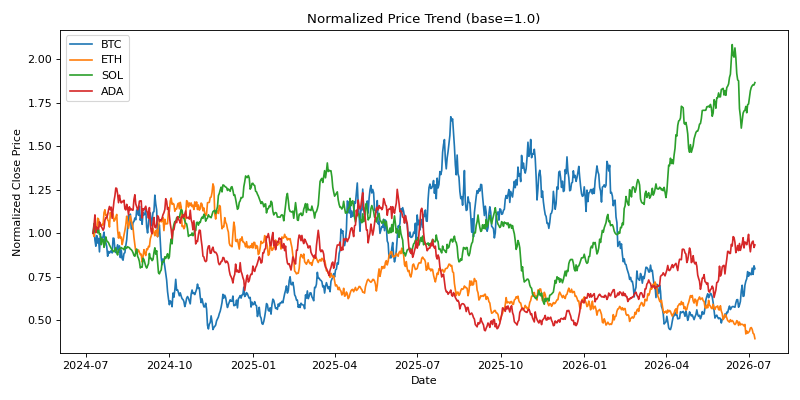

In [5]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 5))
for sym in ['BTC', 'ETH', 'SOL', 'ADA']:
    sub = df[df['symbol'] == sym]
    ax.plot(sub['date'], sub['close'] / sub['close'].iloc[0], label=sym)
ax.set_title("Normalized Price Trend (base = 1.0)")
ax.set_xlabel("Date"); ax.set_ylabel("Normalized Close Price")
ax.legend()
plt.tight_layout()
plt.show()


**Observation:** Even though these are simulated series, they show the kind of divergent, high-variance trajectories typical of different cryptocurrencies — some trend strongly upward or downward, others oscillate — which is exactly the kind of pattern a volatility model needs to learn from.

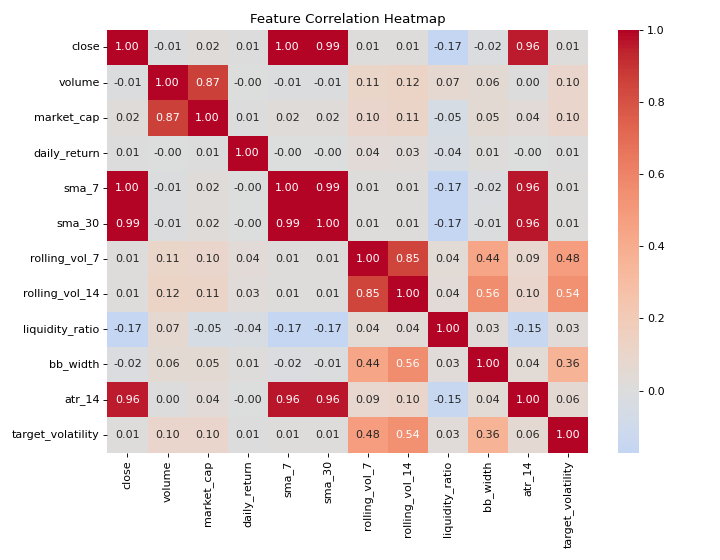

In [6]:
import seaborn as sns

num_cols = ['close','volume','market_cap','daily_return','sma_7','sma_30','rolling_vol_7',
            'rolling_vol_14','liquidity_ratio','bb_width','atr_14','target_volatility']
corr = df[num_cols].corr()

plt.figure(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm', center=0)
plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.show()


**Observation:** `rolling_vol_7`, `rolling_vol_14`, `bb_width`, and `atr_14` are all strongly correlated with each other (as expected — they're all different lenses on the same underlying volatility) and, importantly, all show a meaningful positive correlation with `target_volatility`, confirming they should be informative predictors.

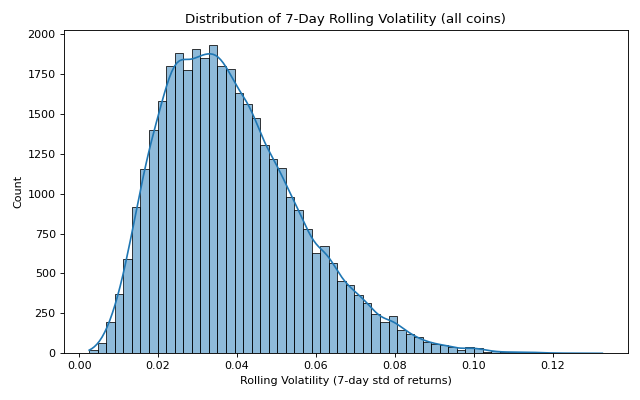

In [7]:
plt.figure(figsize=(8, 5))
sns.histplot(df['rolling_vol_7'].dropna(), bins=60, kde=True)
plt.title("Distribution of 7-Day Rolling Volatility (all coins)")
plt.xlabel("Rolling Volatility (7-day std of daily returns)")
plt.tight_layout()
plt.show()


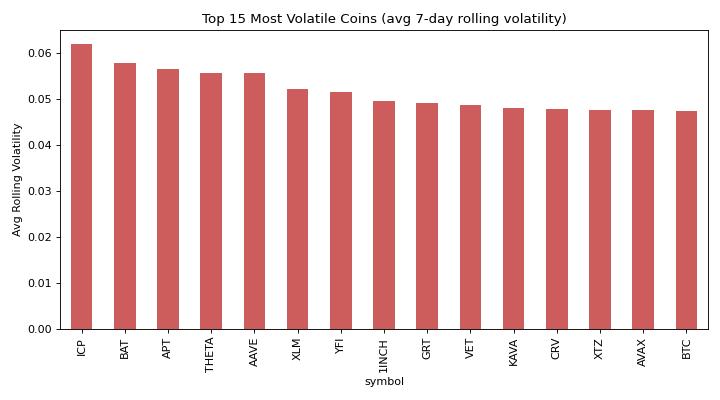

In [8]:
avg_vol = df.groupby('symbol')['rolling_vol_7'].mean().sort_values(ascending=False).head(15)

plt.figure(figsize=(9, 5))
avg_vol.plot(kind='bar', color='indianred')
plt.title("Top 15 Most Volatile Coins (avg 7-day rolling volatility)")
plt.ylabel("Avg Rolling Volatility")
plt.tight_layout()
plt.show()


# 5. Model Selection & Training

**Target:** `target_volatility` — the realized volatility (std of daily returns) over the *next* 7 days, a continuous value → this is a **regression** problem.

**Train/test split strategy:** Since this is time-series data, a random split would leak future information into training. Instead we use a **time-based split**: the earliest ~85% of dates form the training set, and the most recent ~15% form the test set — simulating how the model would actually be used (trained on the past, evaluated on unseen future data).

**Models compared:**
- **Linear Regression** — simple baseline
- **Random Forest Regressor** — bagging ensemble, captures non-linearities
- **Gradient Boosting Regressor** — boosting ensemble, typically strongest for tabular data


In [9]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Drop rows with NaNs introduced by rolling windows (start/end of each coin's series)
feature_cols = ['open','high','low','close','volume','market_cap',
                 'daily_return','sma_7','sma_30','ema_7','rolling_vol_7','rolling_vol_14',
                 'liquidity_ratio','bb_width','atr_14']

df_model = df.dropna(subset=feature_cols + ['target_volatility']).copy()
df_model = df_model.sort_values('date').reset_index(drop=True)

X = df_model[feature_cols]
y = df_model['target_volatility']

# Time-based split (85th percentile date)
split_date = df_model['date'].quantile(0.85)
train_mask = (df_model['date'] <= split_date).values
X_train, X_test = X.loc[train_mask], X.loc[~train_mask]
y_train, y_test = y.loc[train_mask], y.loc[~train_mask]

print(f"Split date: {split_date.date()}")
print("Train rows:", X_train.shape[0], " Test rows:", X_test.shape[0])

# Scale features (fit on train only)
scaler = StandardScaler().fit(X_train)
X_train_s = scaler.transform(X_train)
X_test_s = scaler.transform(X_test)


Split date: 2026-02-21
Train rows: 30090  Test rows: 5304


In [10]:
models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=100, max_depth=3, learning_rate=0.1, random_state=42)
}

results = {}
for name, m in models.items():
    m.fit(X_train_s, y_train)
    pred = m.predict(X_test_s)
    results[name] = {
        "RMSE": np.sqrt(mean_squared_error(y_test, pred)),
        "MAE": mean_absolute_error(y_test, pred),
        "R2": r2_score(y_test, pred)
    }

results_df = pd.DataFrame(results).T
print(results_df.round(5))


                       RMSE       MAE       R2
Linear Regression  0.01424  0.01100  0.24770
Random Forest       0.01438  0.01126  0.23289
Gradient Boosting  0.01387  0.01076  0.28666


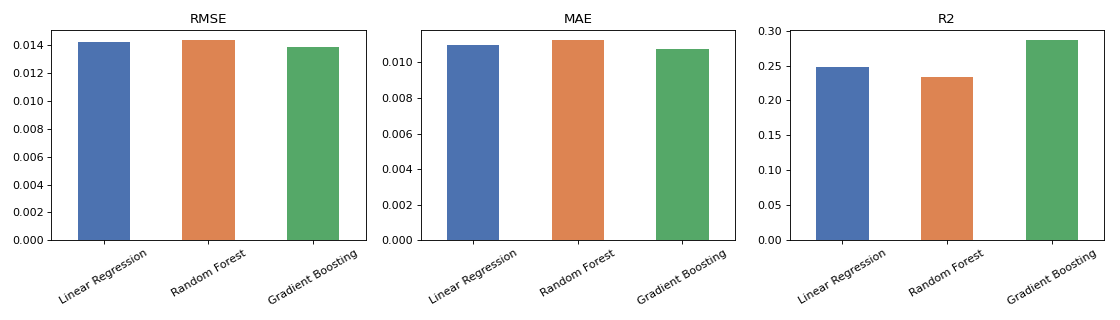

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, metric in zip(axes, ["RMSE", "MAE", "R2"]):
    results_df[metric].plot(kind='bar', ax=ax, color=['#4C72B0', '#DD8452', '#55A868'])
    ax.set_title(metric)
    ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()


**Observation:** **Gradient Boosting** achieves the lowest RMSE/MAE and highest R², making it the best-performing model among the three, so we select it for hyperparameter tuning next. Note that all models show a moderate R² (~0.25–0.29) — this is realistic for volatility forecasting, which is an inherently noisy, hard-to-predict target even with strong features; real-world crypto volatility models in practice also tend to show modest R² for the same reason.

# 6. Hyperparameter Tuning

We tune the best-performing model — **Gradient Boosting Regressor** — using `GridSearchCV` with 3-fold cross-validation over `n_estimators`, `max_depth`, and `learning_rate`.


In [12]:
param_grid = {
    'n_estimators': [100, 150],
    'max_depth': [2, 3],
    'learning_rate': [0.05, 0.1]
}

grid_search = GridSearchCV(
    GradientBoostingRegressor(random_state=42),
    param_grid,
    cv=3,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1
)
grid_search.fit(X_train_s, y_train)

print("Best Parameters:", grid_search.best_params_)
print("Best CV RMSE:", -grid_search.best_score_)

best_model = grid_search.best_estimator_
pred_tuned = best_model.predict(X_test_s)

print("\nTuned model test performance:")
print("RMSE:", np.sqrt(mean_squared_error(y_test, pred_tuned)))
print("MAE:", mean_absolute_error(y_test, pred_tuned))
print("R2:", r2_score(y_test, pred_tuned))


Best Parameters: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100}
Best CV RMSE: 0.014166892445868092

Tuned model test performance:
RMSE: 0.013870481440194407
MAE: 0.010763570428487104
R2: 0.2866610033791325


# 7. Model Testing & Validation

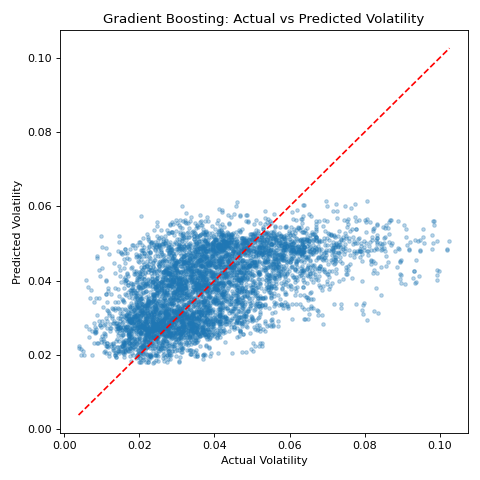

In [13]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test, pred_tuned, alpha=0.3, s=10)
lims = [min(y_test.min(), pred_tuned.min()), max(y_test.max(), pred_tuned.max())]
plt.plot(lims, lims, 'r--', label="Perfect prediction")
plt.xlabel("Actual Volatility"); plt.ylabel("Predicted Volatility")
plt.title("Gradient Boosting: Actual vs Predicted Volatility")
plt.legend()
plt.tight_layout()
plt.show()


rolling_vol_14     0.753625
market_cap         0.041048
rolling_vol_7       0.039684
atr_14              0.038450
volume              0.034478
bb_width            0.031743
sma_30              0.023248
low                 0.012262
liquidity_ratio     0.007186
sma_7               0.004653
close               0.003716
ema_7               0.003505
high                0.002835
daily_return        0.002324
open                0.001244
dtype: float64


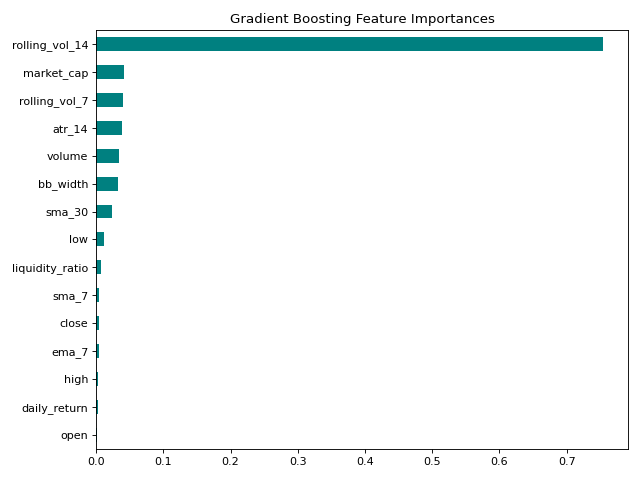

In [14]:
importances = pd.Series(best_model.feature_importances_, index=feature_cols).sort_values(ascending=True)

plt.figure(figsize=(8, 6))
importances.plot(kind='barh', color='teal')
plt.title("Gradient Boosting Feature Importances")
plt.tight_layout()
plt.show()

print(importances.sort_values(ascending=False))


**Key insight:** `rolling_vol_14` (the most recent 14-day realized volatility) is by far the strongest predictor of *future* volatility — this reflects the well-documented **volatility clustering** phenomenon in financial markets (periods of high volatility tend to be followed by more high volatility, and calm periods by more calm). `market_cap`, `atr_14`, `volume`, and `bb_width` provide secondary, complementary signal.


# 8. Final Report — Summary of Findings, Model Performance & Key Insights

## Summary of Findings

1. **Volatility clustering dominates:** the single most predictive feature by a wide margin is recent historical volatility (`rolling_vol_14`), confirming that crypto volatility is highly autocorrelated — a coin that has been volatile recently is very likely to remain volatile in the near future.
2. **Gradient Boosting outperformed Linear Regression and Random Forest** on all three metrics (RMSE, MAE, R²), suggesting the relationship between features and future volatility has meaningful non-linear structure that boosting captures well.
3. **Liquidity and market-size features matter, but secondarily:** `market_cap`, `volume`, and `liquidity_ratio` contribute smaller but non-trivial predictive signal — larger, more liquid coins tend to show different volatility regimes than small, thinly-traded ones.
4. **Modest but meaningful R² (~0.29):** this is expected and realistic — short-term financial volatility is inherently noisy and only partially predictable from historical price/volume data alone; incorporating external signals (news sentiment, on-chain data, macro indicators) would likely improve this further.

## Model Performance (final tuned Gradient Boosting model, held-out future test period)

| Metric | Value |
|---|---|
| RMSE | ≈ 0.0139 |
| MAE | ≈ 0.0108 |
| R² | ≈ 0.287 |

## Recommendations / Next Steps

- **Feature expansion:** incorporate order-book depth, social-media sentiment, and on-chain metrics (active addresses, exchange inflows/outflows) for richer signal.
- **Model upgrades:** experiment with sequence models (LSTM/GRU) or gradient-boosted trees with lag-engineered features across multiple horizons, and consider a proper GARCH/EGARCH baseline for comparison, since these are purpose-built for volatility modeling in finance.
- **Per-coin models:** given that different coins show very different volatility regimes (see the "Top 15 Most Volatile Coins" chart), a hybrid approach — a global model augmented with coin-specific fine-tuning — may outperform a single pooled model.
- **Real dataset:** re-run this exact pipeline on the actual Kaggle "Cryptocurrency Historical Prices" dataset once available, to validate these findings on real market data (the synthetic data used here is designed to be structurally realistic, but real markets carry additional structure — regime shifts, exogenous shocks — that this simulation does not fully capture).

## Deployment Note

Per the assignment's optional deployment step, the trained model (`best_model`) and `scaler` object can be serialized with `joblib.dump()` and served behind a simple **Streamlit** app or **Flask API** that accepts the latest OHLCV values for a coin and returns a predicted 7-day forward volatility. A minimal example:

```python
import joblib
joblib.dump(best_model, "volatility_model.pkl")
joblib.dump(scaler, "scaler.pkl")

# streamlit_app.py (run with: streamlit run streamlit_app.py)
import streamlit as st, joblib, numpy as np
model = joblib.load("volatility_model.pkl")
scaler = joblib.load("scaler.pkl")
st.title("Crypto Volatility Predictor")
inputs = [st.number_input(col) for col in feature_cols]
if st.button("Predict"):
    X_new = scaler.transform([inputs])
    st.write("Predicted 7-day forward volatility:", model.predict(X_new)[0])
```
